<div style="background:linear-gradient(135deg,#1A5276 0%,#2E86C1 100%);padding:40px 36px 32px 36px;border-radius:10px;margin-bottom:8px;">
  <p style="color:#AED6F1;font-size:13px;margin:0 0 6px 0;letter-spacing:2px;">CURSO 8 · MÓDULO 2 · CLASE 5</p>
  <h1 style="color:white;font-size:36px;margin:0 0 10px 0;font-weight:700;">Regresión Logística desde el GLM</h1>
  <p style="color:#AED6F1;font-size:16px;margin:0 0 24px 0;font-style:italic;">De la recta a la curva — modelar probabilidades correctamente</p>
  <hr style="border-color:#5DADE2;margin:0 0 20px 0;">
  <p style="color:#EBF5FB;font-size:13px;margin:0;">📌 <strong>Docente:</strong> Josef Rodriguez &nbsp;·&nbsp; <strong>Módulo 2:</strong> Regresión Logística &nbsp;·&nbsp; <strong>Duración:</strong> 2 horas</p>
</div>

## Objetivos
| # | Al terminar podés |
|---|-------------------|
| 1 | Explicar por qué OLS falla para clasificación binaria |
| 2 | Derivar la función logit desde el modelo lineal generalizado |
| 3 | Interpretar odds, log-odds y probabilidades |
| 4 | Implementar regresión logística con gradient descent y sklearn |
| 5 | Leer e interpretar la curva sigmoide en contexto de negocio |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit   # función sigmoide
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({'figure.dpi':110,'font.size':11,'axes.spines.top':False,'axes.spines.right':False})
SEED=42; np.random.seed(SEED)
print('✅ Setup listo')

✅ Setup listo


---
## 1. ¿Por qué OLS falla para clasificar?

OLS predice valores en (-∞, +∞). Una probabilidad debe estar en [0,1].

Además, OLS asume varianza constante — pero con y ∈ {0,1}, la varianza de y depende de p: **Var(y) = p(1-p)**.

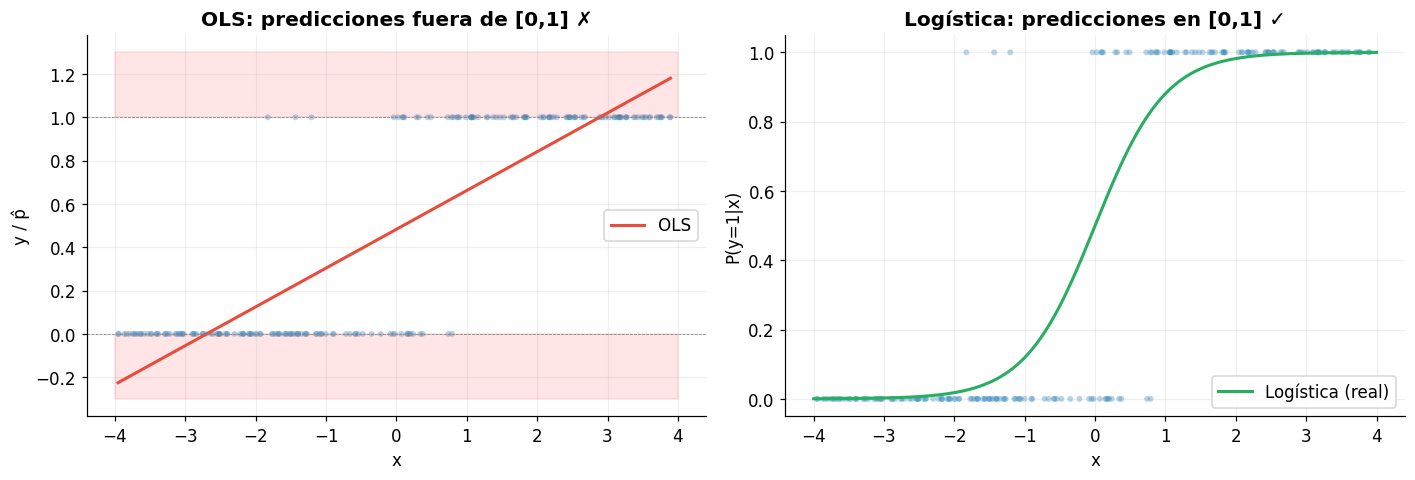

OLS: rango predicciones = [-0.23, 1.18]  ← sale de [0,1]


In [2]:
# Demostrar el problema de OLS para clasificación
np.random.seed(SEED)
n = 200
x = np.random.uniform(-4, 4, n)
# Probabilidad real
p_real = expit(2 * x)              # sigmoide
y = np.random.binomial(1, p_real)  # variable binaria

# OLS
beta_ols = np.polyfit(x, y, 1)
y_ols = np.polyval(beta_ols, x)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(x, y, alpha=0.35, s=15, color='#2E86C1', edgecolors='none')
axes[0].plot(np.sort(x), np.polyval(beta_ols, np.sort(x)), color='#E74C3C', lw=2, label='OLS')
axes[0].axhline(0, color='gray', lw=0.5, linestyle='--')
axes[0].axhline(1, color='gray', lw=0.5, linestyle='--')
axes[0].fill_between([-4,4], [-0.3,-0.3], [0,0], alpha=0.1, color='red')
axes[0].fill_between([-4,4], [1,1], [1.3,1.3], alpha=0.1, color='red')
axes[0].set_title('OLS: predicciones fuera de [0,1] ✗', fontweight='bold')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y / p̂')
axes[0].legend(); axes[0].grid(True, alpha=0.2)

xr = np.linspace(-4, 4, 300)
axes[1].scatter(x, y, alpha=0.35, s=15, color='#2E86C1', edgecolors='none')
axes[1].plot(xr, expit(2*xr), color='#27AE60', lw=2, label='Logística (real)')
axes[1].set_title('Logística: predicciones en [0,1] ✓', fontweight='bold')
axes[1].set_xlabel('x'); axes[1].set_ylabel('P(y=1|x)')
axes[1].legend(); axes[1].grid(True, alpha=0.2)

plt.tight_layout(); plt.show()
print(f'OLS: rango predicciones = [{y_ols.min():.2f}, {y_ols.max():.2f}]  ← sale de [0,1]')

---
## 2. Del GLM a la función logit

**Familia:** Bernoulli — y ∈ {0,1}, E[y|x] = p

**Función de enlace (link function):** logit
$$\text{logit}(p) = \log\frac{p}{1-p} = \mathbf{x}^\top\boldsymbol{\beta}$$

Despejando p:
$$p = \sigma(\mathbf{x}^\top\boldsymbol{\beta}) = \frac{1}{1+e^{-\mathbf{x}^\top\boldsymbol{\beta}}}$$

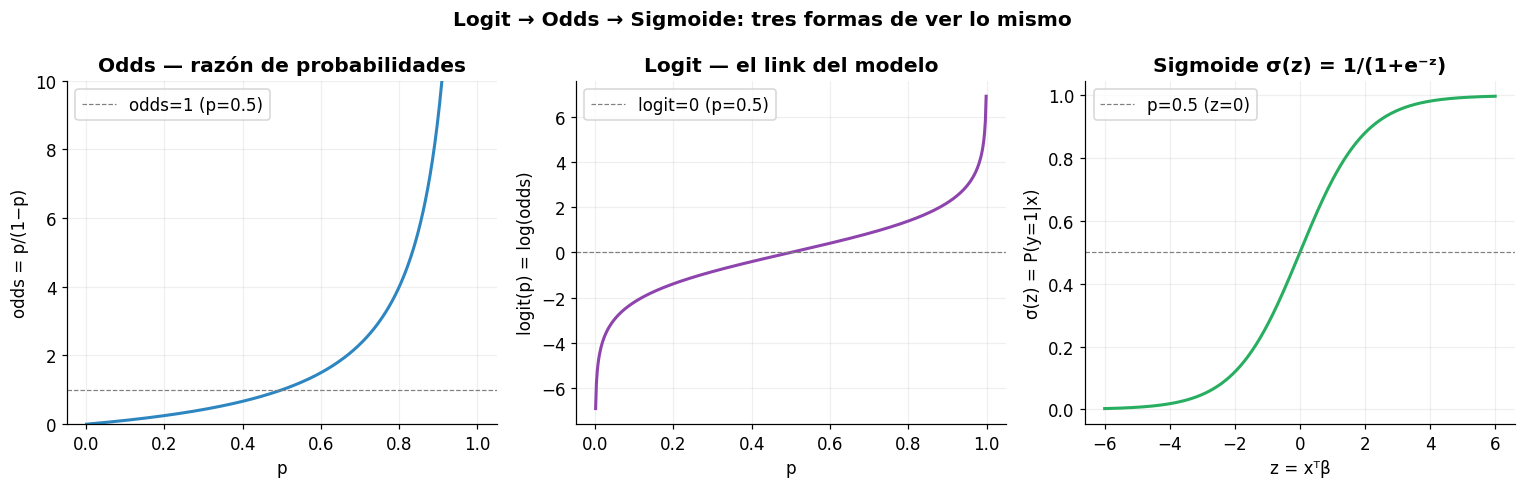

In [3]:
# Visualizar logit, odds y sigmoide
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

p_vals = np.linspace(0.001, 0.999, 500)
z_vals = np.linspace(-6, 6, 500)

# Odds = p/(1-p)
axes[0].plot(p_vals, p_vals/(1-p_vals), color='#2E86C1', lw=2)
axes[0].axhline(1, color='gray', lw=0.8, linestyle='--', label='odds=1 (p=0.5)')
axes[0].set_xlabel('p'); axes[0].set_ylabel('odds = p/(1−p)')
axes[0].set_title('Odds — razón de probabilidades', fontweight='bold')
axes[0].set_ylim(0, 10); axes[0].legend(); axes[0].grid(True, alpha=0.2)

# Log-odds (logit)
axes[1].plot(p_vals, np.log(p_vals/(1-p_vals)), color='#8E44AD', lw=2)
axes[1].axhline(0, color='gray', lw=0.8, linestyle='--', label='logit=0 (p=0.5)')
axes[1].set_xlabel('p'); axes[1].set_ylabel('logit(p) = log(odds)')
axes[1].set_title('Logit — el link del modelo', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.2)

# Sigmoide
axes[2].plot(z_vals, expit(z_vals), color='#27AE60', lw=2)
axes[2].axhline(0.5, color='gray', lw=0.8, linestyle='--', label='p=0.5 (z=0)')
axes[2].set_xlabel('z = xᵀβ'); axes[2].set_ylabel('σ(z) = P(y=1|x)')
axes[2].set_title('Sigmoide σ(z) = 1/(1+e⁻ᶻ)', fontweight='bold')
axes[2].legend(); axes[2].grid(True, alpha=0.2)

plt.suptitle('Logit → Odds → Sigmoide: tres formas de ver lo mismo', fontweight='bold')
plt.tight_layout(); plt.show()

In [4]:
# Propiedades de la sigmoide
print('Propiedades de σ(z) = 1/(1+e⁻ᶻ):')
print(f'  σ(0)  = {expit(0):.4f}   ← p=0.5 cuando z=0')
print(f'  σ(2)  = {expit(2):.4f}   ← odds = e²={np.exp(2):.2f}')
print(f'  σ(-2) = {expit(-2):.4f}   ← simétrica: σ(-z)=1-σ(z)')
print(f'  σ(10) = {expit(10):.6f}  ← converge a 1')
print(f'  σ(-10)= {expit(-10):.6f}  ← converge a 0')
print(f'\nDerivada: dσ/dz = σ(z)(1-σ(z))  ← útil para gradient descent')

Propiedades de σ(z) = 1/(1+e⁻ᶻ):
  σ(0)  = 0.5000   ← p=0.5 cuando z=0
  σ(2)  = 0.8808   ← odds = e²=7.39
  σ(-2) = 0.1192   ← simétrica: σ(-z)=1-σ(z)
  σ(10) = 0.999955  ← converge a 1
  σ(-10)= 0.000045  ← converge a 0

Derivada: dσ/dz = σ(z)(1-σ(z))  ← útil para gradient descent


---
## 3. Interpretación de coeficientes

En regresión logística, **eˢᵝʲ** = factor multiplicativo del odds cuando xⱼ aumenta en 1 unidad.

- βⱼ > 0 → eˢᵝʲ > 1 → odds aumentan → mayor probabilidad de y=1
- βⱼ < 0 → eˢᵝʲ < 1 → odds disminuyen → menor probabilidad de y=1

In [5]:
# Interpretación con caso de crédito
np.random.seed(SEED)
n_cred = 500

ingresos_std = np.random.randn(n_cred)      # estandarizado
deuda_ratio  = np.random.randn(n_cred)      # estandarizado
historial    = np.random.randn(n_cred)      # estandarizado

# P(default) = sigmoide(β₀ + β₁·ingresos + β₂·deuda + β₃·historial)
beta_cred = np.array([-1.5, -1.2, 1.8, -0.9])   # β₀,β₁,β₂,β₃
X_cred = np.column_stack([np.ones(n_cred), ingresos_std, deuda_ratio, historial])
p_default = expit(X_cred @ beta_cred)
y_default = np.random.binomial(1, p_default)

print('Coeficientes e interpretación (caso: probabilidad de default):')
names_cred = ['intercepto','ingresos','deuda_ratio','historial_negativo']
for nm, b in zip(names_cred, beta_cred):
    or_val = np.exp(b)
    direction = '↑ riesgo' if b > 0 else '↓ riesgo'
    print(f'  {nm:22s}: β={b:+.2f}  OR=e^β={or_val:.3f}  → {direction}')

print('\nInterpretación:')
print('  OR > 1 → factor de riesgo (aumenta probabilidad de default)')
print('  OR < 1 → factor protector (reduce probabilidad de default)')

Coeficientes e interpretación (caso: probabilidad de default):
  intercepto            : β=-1.50  OR=e^β=0.223  → ↓ riesgo
  ingresos              : β=-1.20  OR=e^β=0.301  → ↓ riesgo
  deuda_ratio           : β=+1.80  OR=e^β=6.050  → ↑ riesgo
  historial_negativo    : β=-0.90  OR=e^β=0.407  → ↓ riesgo

Interpretación:
  OR > 1 → factor de riesgo (aumenta probabilidad de default)
  OR < 1 → factor protector (reduce probabilidad de default)


---
## 4. Log-verosimilitud y estimación MLE

OLS minimiza SSE. Logística **maximiza la log-verosimilitud**:

$$\ell(\boldsymbol{\beta}) = \sum_{i=1}^n \left[y_i \log(p_i) + (1-y_i)\log(1-p_i)\right]$$

Equivalentemente, minimiza la **binary cross-entropy**:
$$L = -\frac{1}{n}\ell(\boldsymbol{\beta})$$

In [6]:
# Implementar log-verosimilitud y gradient descent desde cero
def sigmoid(z):
    return expit(z)   # numéricamente estable

def log_likelihood(beta, X, y):
    p = sigmoid(X @ beta)
    p = np.clip(p, 1e-10, 1 - 1e-10)   # evitar log(0)
    return np.sum(y * np.log(p) + (1-y) * np.log(1-p))

def neg_log_lik(beta, X, y):
    return -log_likelihood(beta, X, y) / len(y)

def gradient(beta, X, y):
    p = sigmoid(X @ beta)
    return -X.T @ (y - p) / len(y)   # gradiente de la neg-log-lik

print('Funciones implementadas:')
print('  sigmoid(z) = 1/(1+e^(-z))')
print('  log_likelihood: Σ yᵢ·log(pᵢ) + (1-yᵢ)·log(1-pᵢ)')
print('  neg_log_lik: -ℓ/n  (minimizar = maximizar verosimilitud)')

# Verificar: ¿la log-verosimilitud crece con betas correctos?
beta_test = np.array([-1.5, -1.2, 1.8, -0.9])
beta_zero = np.zeros(4)
print(f'\nℓ con β_real = {log_likelihood(beta_test, X_cred, y_default):.2f}')
print(f'ℓ con β=0    = {log_likelihood(beta_zero, X_cred, y_default):.2f}')

Funciones implementadas:
  sigmoid(z) = 1/(1+e^(-z))
  log_likelihood: Σ yᵢ·log(pᵢ) + (1-yᵢ)·log(1-pᵢ)
  neg_log_lik: -ℓ/n  (minimizar = maximizar verosimilitud)

ℓ con β_real = -176.98
ℓ con β=0    = -346.57


Estimación de β por distintos métodos:
  β_real     : [-1.5 -1.2  1.8 -0.9]
  GD (300 it): [-1.711  -1.3143  1.8745 -0.8394]
  MLE (BFGS) : [-1.7193 -1.3215  1.8854 -0.8441]


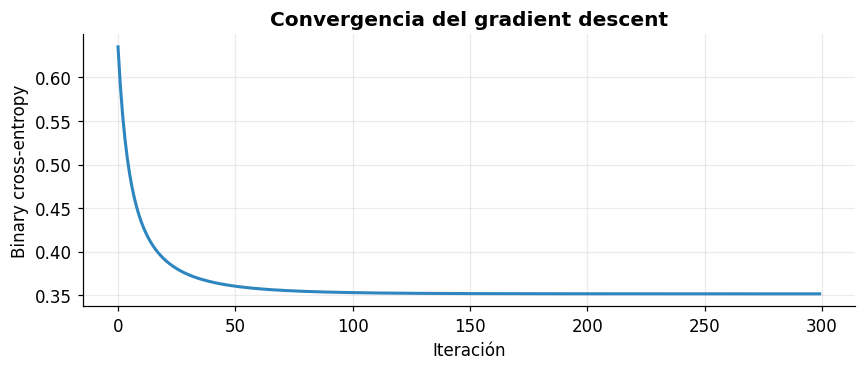

In [7]:
# Gradient descent manual
np.random.seed(SEED)
beta_gd = np.zeros(4)   # inicializar en 0
alpha    = 0.5          # learning rate
n_iter   = 300
history  = []

for i in range(n_iter):
    grad      = gradient(beta_gd, X_cred, y_default)
    beta_gd  -= alpha * grad
    history.append(neg_log_lik(beta_gd, X_cred, y_default))

# Comparar con scipy.optimize
result = minimize(neg_log_lik, np.zeros(4), args=(X_cred, y_default),
                  method='BFGS', jac=gradient)
beta_mle = result.x

print('Estimación de β por distintos métodos:')
print(f'  β_real     : {beta_cred}')
print(f'  GD (300 it): {beta_gd.round(4)}')
print(f'  MLE (BFGS) : {beta_mle.round(4)}')

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(history, color='#2E86C1', lw=2)
ax.set_xlabel('Iteración'); ax.set_ylabel('Binary cross-entropy')
ax.set_title('Convergencia del gradient descent', fontweight='bold')
ax.grid(True, alpha=0.25); plt.tight_layout(); plt.show()

---
## 5. Implementación con sklearn

En producción usamos `LogisticRegression` de sklearn, que usa LBFGS internamente.

In [8]:
# Pipeline completo con sklearn
X_tr, X_te, y_tr, y_te = train_test_split(X_cred, y_default, test_size=0.25, random_state=SEED)

lr = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
lr.fit(X_tr, y_tr)

y_pred  = lr.predict(X_te)
y_proba = lr.predict_proba(X_te)[:, 1]

print('Coeficientes sklearn:')
print('  intercepto:', lr.intercept_.round(4))
print('  coefs:     ', lr.coef_[0].round(4))
print(f'\nAccuracy test: {accuracy_score(y_te, y_pred):.4f}')
print('\nReporte de clasificación:')
print(classification_report(y_te, y_pred, target_names=['No default','Default']))

Coeficientes sklearn:
  intercepto: [-0.8402]
  coefs:      [-0.8402 -1.3177  1.8932 -0.9889]

Accuracy test: 0.8320

Reporte de clasificación:
              precision    recall  f1-score   support

  No default       0.88      0.90      0.89        93
     Default       0.69      0.62      0.66        32

    accuracy                           0.83       125
   macro avg       0.78      0.76      0.77       125
weighted avg       0.83      0.83      0.83       125



/Users/josefrodriguez/repos/modelos_estadisticos/modelos_estadisticos/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


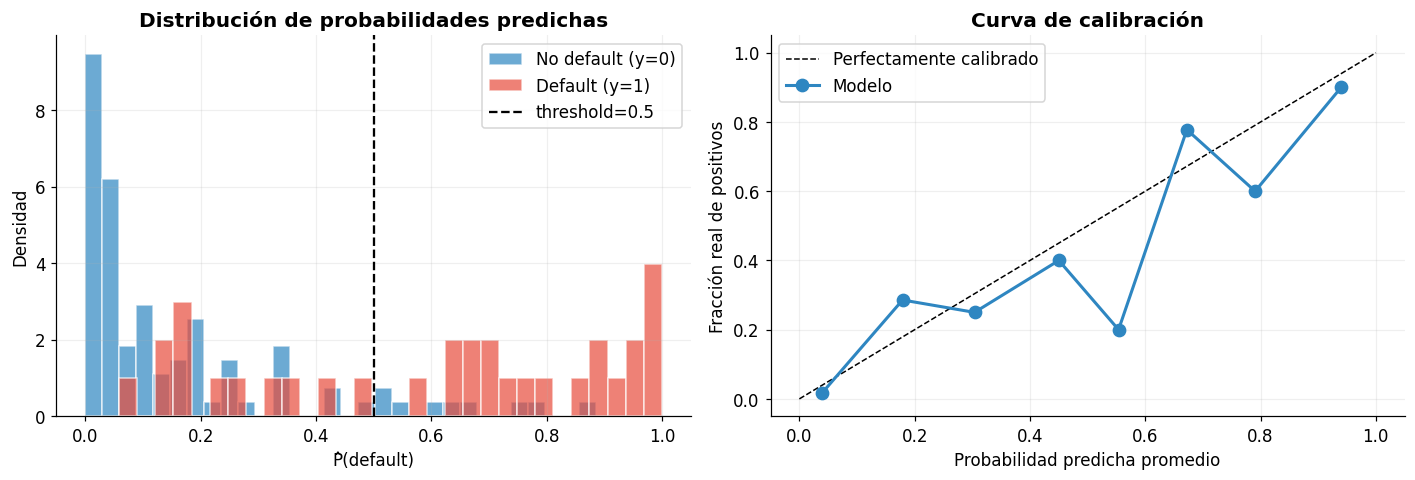

In [9]:
# Visualizar probabilidades predichas por clase real
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Distribución de probabilidades
for cls, color, label in [(0,'#2E86C1','No default (y=0)'), (1,'#E74C3C','Default (y=1)')]:
    mask = y_te == cls
    axes[0].hist(y_proba[mask], bins=30, alpha=0.7, color=color,
                 edgecolor='white', label=label, density=True)
axes[0].axvline(0.5, color='black', lw=1.5, linestyle='--', label='threshold=0.5')
axes[0].set_xlabel('P̂(default)'); axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de probabilidades predichas', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.2)

# Calibración: prob predicha vs frecuencia real
from sklearn.calibration import calibration_curve
frac_pos, mean_pred = calibration_curve(y_te, y_proba, n_bins=8)
axes[1].plot([0,1],[0,1],'k--',lw=1,label='Perfectamente calibrado')
axes[1].plot(mean_pred, frac_pos,'o-',color='#2E86C1',lw=2,markersize=8,label='Modelo')
axes[1].set_xlabel('Probabilidad predicha promedio')
axes[1].set_ylabel('Fracción real de positivos')
axes[1].set_title('Curva de calibración', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.2)

plt.tight_layout(); plt.show()

---
## 6. Aplicación industrial: Scoring de crédito

Ejemplo completo de un pipeline de scoring bancario real.

In [10]:
# Dataset de scoring completo
np.random.seed(SEED)
n_bank = 2000

ingresos  = np.random.normal(50000, 20000, n_bank)
antigu    = np.random.randint(0, 30, n_bank).astype(float)
deuda_r   = np.random.uniform(0.05, 0.85, n_bank)
num_prod  = np.random.randint(1, 6, n_bank).astype(float)
edad      = np.random.randint(20, 70, n_bank).astype(float)

# P(default) real
logit_real = (-2.5
              - 0.00003 * ingresos
              + 0.01    * antigu
              + 3.0     * deuda_r
              - 0.2     * num_prod
              - 0.02    * edad)
p_def = expit(logit_real)
y_bank = np.random.binomial(1, p_def)

print(f'Tasa de default: {y_bank.mean():.1%}')
print(f'Clientes: {n_bank:,}')

# Pipeline
feats_bank = ['ingresos','antiguedad','deuda_ratio','num_productos','edad']
X_bank_raw = np.column_stack([ingresos, antigu, deuda_r, num_prod, edad])
sc = StandardScaler()
X_bank_sc  = sc.fit_transform(X_bank_raw)

Xb_tr,Xb_te,yb_tr,yb_te = train_test_split(X_bank_sc,y_bank,test_size=0.2,random_state=SEED)
lr_bank = LogisticRegression(penalty=None, solver='lbfgs', max_iter=500)
lr_bank.fit(Xb_tr, yb_tr)

yb_proba = lr_bank.predict_proba(Xb_te)[:,1]
print(f'Accuracy: {accuracy_score(yb_te, yb_proba>0.5):.4f}')

Tasa de default: 2.4%
Clientes: 2,000
Accuracy: 0.9750


/Users/josefrodriguez/repos/modelos_estadisticos/modelos_estadisticos/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [11]:
# Tabla de coeficientes con odds ratios
print('Tabla de coeficientes — Modelo de Scoring:')
print(f'{"Feature":20s} {"β̂":>8s} {"OR=e^β":>10s} {"Efecto":>15s}')
print('─'*58)
all_names = ['intercepto'] + feats_bank
all_coefs = np.concatenate([lr_bank.intercept_, lr_bank.coef_[0]])
for nm, b in zip(all_names, all_coefs):
    OR = np.exp(b)
    efecto = '→ aumenta riesgo' if b > 0 else '→ reduce riesgo'
    print(f'  {nm:18s} {b:>8.4f} {OR:>10.4f}  {efecto}')

# Predicción para nuevos clientes
nuevos = np.array([[75000,8,0.25,3,35],[22000,1,0.75,1,25],[55000,15,0.40,4,50]])
nuevos_sc = sc.transform(nuevos)
p_nuevos  = lr_bank.predict_proba(nuevos_sc)[:,1]
labels_n  = ['A (bueno)','B (riesgoso)','C (intermedio)']
print('\nPredicciones para nuevos solicitantes:')
for lbl, p in zip(labels_n, p_nuevos):
    decision = '✓ APROBAR' if p < 0.3 else ('⚠ REVISAR' if p < 0.5 else '✗ RECHAZAR')
    print(f'  {lbl:15s}: P(default)={p:.3f}  {decision}')

Tabla de coeficientes — Modelo de Scoring:
Feature                    β̂     OR=e^β          Efecto
──────────────────────────────────────────────────────────
  intercepto          -4.3126     0.0134  → reduce riesgo
  ingresos            -0.6804     0.5064  → reduce riesgo
  antiguedad          -0.0363     0.9644  → reduce riesgo
  deuda_ratio          0.7467     2.1100  → aumenta riesgo
  num_productos       -0.4438     0.6416  → reduce riesgo
  edad                -0.2009     0.8180  → reduce riesgo

Predicciones para nuevos solicitantes:
  A (bueno)      : P(default)=0.004  ✓ APROBAR
  B (riesgoso)   : P(default)=0.199  ✓ APROBAR
  C (intermedio) : P(default)=0.007  ✓ APROBAR


---
## Conclusiones

<div style="background:#EBF5FB;border-left:5px solid #2E86C1;padding:20px 24px;border-radius:0 8px 8px 0;">

**01 · Logística = OLS con función de enlace logit**
No es un modelo distinto — es un GLM con Bernoulli + logit. La estructura matricial es la misma.

**02 · Los coeficientes se interpretan en odds ratios**
eˢᵝʲ = factor por el que se multiplican los odds al incrementar xⱼ en 1 unidad.

**03 · MLE reemplaza a OLS**
No hay fórmula cerrada. Se optimiza iterativamente — gradient descent o BFGS.

</div>

---
<div style="background:#1A5276;color:white;padding:20px 24px;border-radius:8px;">
<strong>Próxima clase</strong><br>
Deviance · AIC · Wald test · Pseudo R² · Curvas ROC y AUC<br>
<em>Docente: Josef Rodriguez · Curso 8 · Módulo 2</em>
</div>